In [5]:
from __future__ import print_function, division
from PyAstronomy import pyasl
import numpy as np
import matplotlib.pylab as plt



In [25]:
# Create the template
tw = np.linspace(4900, 5100, 1000)
tf = np.exp(-(tw-5004.0)**2/(2.*0.1**2))


In [26]:
#!pip install git+https://github.com/sczesla/PyAstronomy.git

In [27]:
# Create data, which are not that well sampled
dw = np.linspace(4900, 5100, 200)
df = np.exp(-(dw-5004.17)**2/(2.*0.1**2))


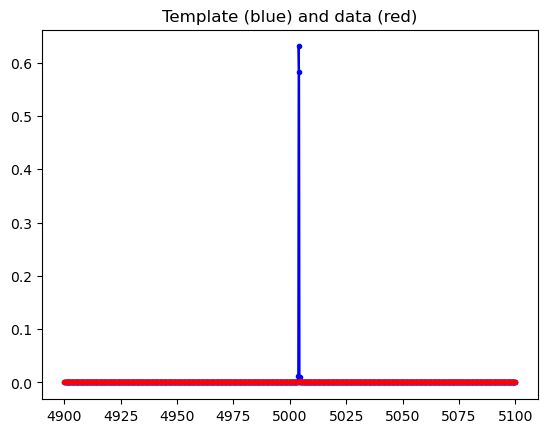

In [28]:
# Plot template and data
plt.title("Template (blue) and data (red)")
plt.plot(tw, tf, 'b.-')
plt.plot(dw, df, 'r.-')
plt.show()


In [29]:
# Carry out the cross-correlation.
# The RV-range is -30 - +30 km/s in steps of 0.6 km/s.
# The first and last 20 points of the data are skipped.
rv, cc = pyasl.crosscorrRV(dw, df, tw, tf, -150., 150., 30./50., skipedge=20)

# Find the index of maximum cross-correlation function
maxind = np.argmax(cc)

print("Cross-correlation function is maximized at dRV = ", rv[maxind], " km/s")
if rv[maxind] > 0.0:
    print("  A red-shift with respect to the template")
else:
    print("  A blue-shift with respect to the template")



Cross-correlation function is maximized at dRV =  36.59999999999823  km/s
  A red-shift with respect to the template


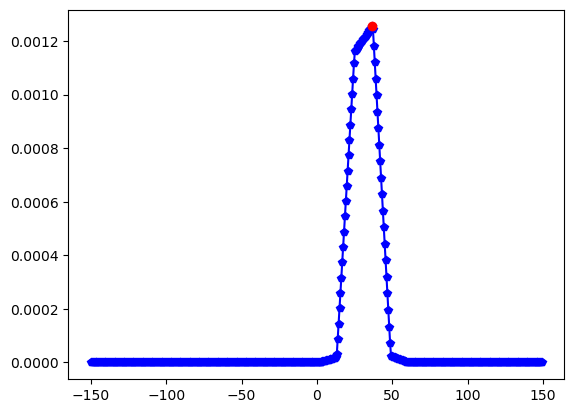

In [30]:
plt.plot(rv, cc, 'bp-')
plt.plot(rv[maxind], cc[maxind], 'ro')
plt.show()